Saved: u_mean_error.png
Saved: v_mean_error.png
Saved: uu_stress_error.png
Saved: vv_stress_error.png
Saved: uv_stress_error.png
Saved: temporal_l2_error.png


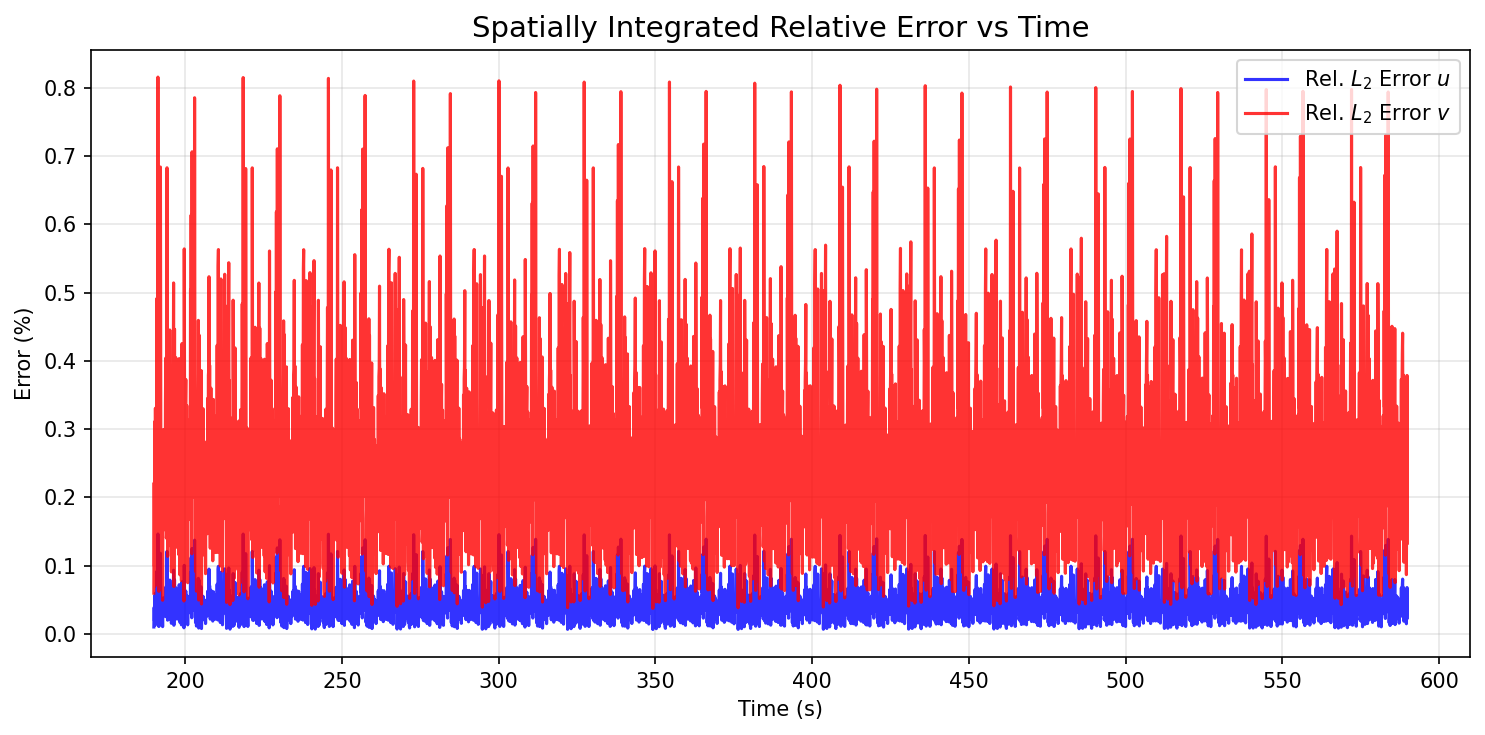

In [3]:
import os
import h5py
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

# 1. Config
output_dir = "/media/chris-remote/Projects/ONeill/estimation/output/DNS_CC_Re150_Mazi"
os.makedirs(output_dir, exist_ok=True)
results_h5 = os.path.join(output_dir, "inference_results.h5")
grid_h5 = os.path.join(output_dir, "dns_regular_0.02D_2d.h5")

# 2. Data Loading & Statistics
with h5py.File(results_h5, 'r') as f:
    ux_p, uy_p = f['ux_pred'][:], f['uy_pred'][:]
    ux_t, uy_t = f['ux_true'][:], f['uy_true'][:]
    time = f['time'][:]

with h5py.File(grid_h5, 'r') as f_grid:
    x, y = f_grid['x'][:], f_grid['y'][:]

# Reshape and Compute Averages
Nx, Ny = len(x), len(y)
ux_p, uy_p = ux_p.reshape(-1, Ny, Nx), uy_p.reshape(-1, Ny, Nx)
ux_t, uy_t = ux_t.reshape(-1, Ny, Nx), uy_t.reshape(-1, Ny, Nx)

def get_stats(u, v):
    u_m, v_m = np.mean(u, axis=0), np.mean(v, axis=0)
    up, vp = u - u_m, v - v_m
    return u_m, v_m, np.mean(up**2, axis=0), np.mean(vp**2, axis=0), np.mean(up*vp, axis=0)

up_m, vp_m, uup, vvp, uvp = get_stats(ux_p, uy_p)
ut_m, vt_m, uut, vvt, uvt = get_stats(ux_t, uy_t)

# Define Error Quantities
errors = {
    "u_mean_error": (up_m - ut_m, r"Mean $u$ Error: $\bar{u}_{pred} - \bar{u}_{true}$"),
    "v_mean_error": (vp_m - vt_m, r"Mean $v$ Error: $\bar{v}_{pred} - \bar{v}_{true}$"),
    "uu_stress_error": (uup - uut, r"Reynolds Stress Error: $\overline{u'u'}_{pred} - \overline{u'u'}_{true}$"),
    "vv_stress_error": (vvp - vvt, r"Reynolds Stress Error: $\overline{v'v'}_{pred} - \overline{v'v'}_{true}$"),
    "uv_stress_error": (uvp - uvt, r"Reynolds Stress Error: $\overline{u'v'}_{pred} - \overline{u'v'}_{true}$")
}

# 3. Plotting Function
def plot_error_contour(data, title, filename):
    fig, ax = plt.subplots(figsize=(10, 4), dpi=150)
    
    # Force symmetry around zero
    vmax = np.max(np.abs(data))
    if vmax == 0: vmax = 1e-6 # Avoid div by zero
    
    extent = [x.min(), x.max(), y.min(), y.max()]
    im = ax.imshow(data, extent=extent, origin='lower', cmap='bwr', vmin=-vmax, vmax=vmax)
    
    # Add Cylinder
    ax.add_patch(Circle((0, 0), 0.5, color='gray', zorder=10, alpha=0.8))
    
    ax.set_title(title, fontsize=14)
    ax.set_xlabel('x/D')
    ax.set_ylabel('y/D')
    fig.colorbar(im, ax=ax, label='Absolute Error')
    
    plt.tight_layout()
    save_path = os.path.join(output_dir, f"{filename}.png")
    plt.savefig(save_path)
    plt.close(fig)
    print(f"Saved: {filename}.png")

# Generate Spatial Plots
for key, (data, title) in errors.items():
    plot_error_contour(data, title, key)

# 4. Temporal Integrated Error Plot
plt.figure(figsize=(10, 5), dpi=150)
err_u = np.sqrt(np.sum((ux_p - ux_t)**2, axis=(1, 2))) / np.sqrt(np.sum(ux_t**2, axis=(1, 2)))
err_v = np.sqrt(np.sum((uy_p - uy_t)**2, axis=(1, 2))) / np.sqrt(np.sum(uy_t**2, axis=(1, 2)))

plt.plot(time, err_u * 100, label=r'Rel. $L_2$ Error $u$', color='blue', alpha=0.8)
plt.plot(time, err_v * 100, label=r'Rel. $L_2$ Error $v$', color='red', alpha=0.8)

plt.title("Spatially Integrated Relative Error vs Time", fontsize=14)
plt.xlabel("Time (s)")
plt.ylabel("Error (%)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "temporal_l2_error.png"))
print("Saved: temporal_l2_error.png")

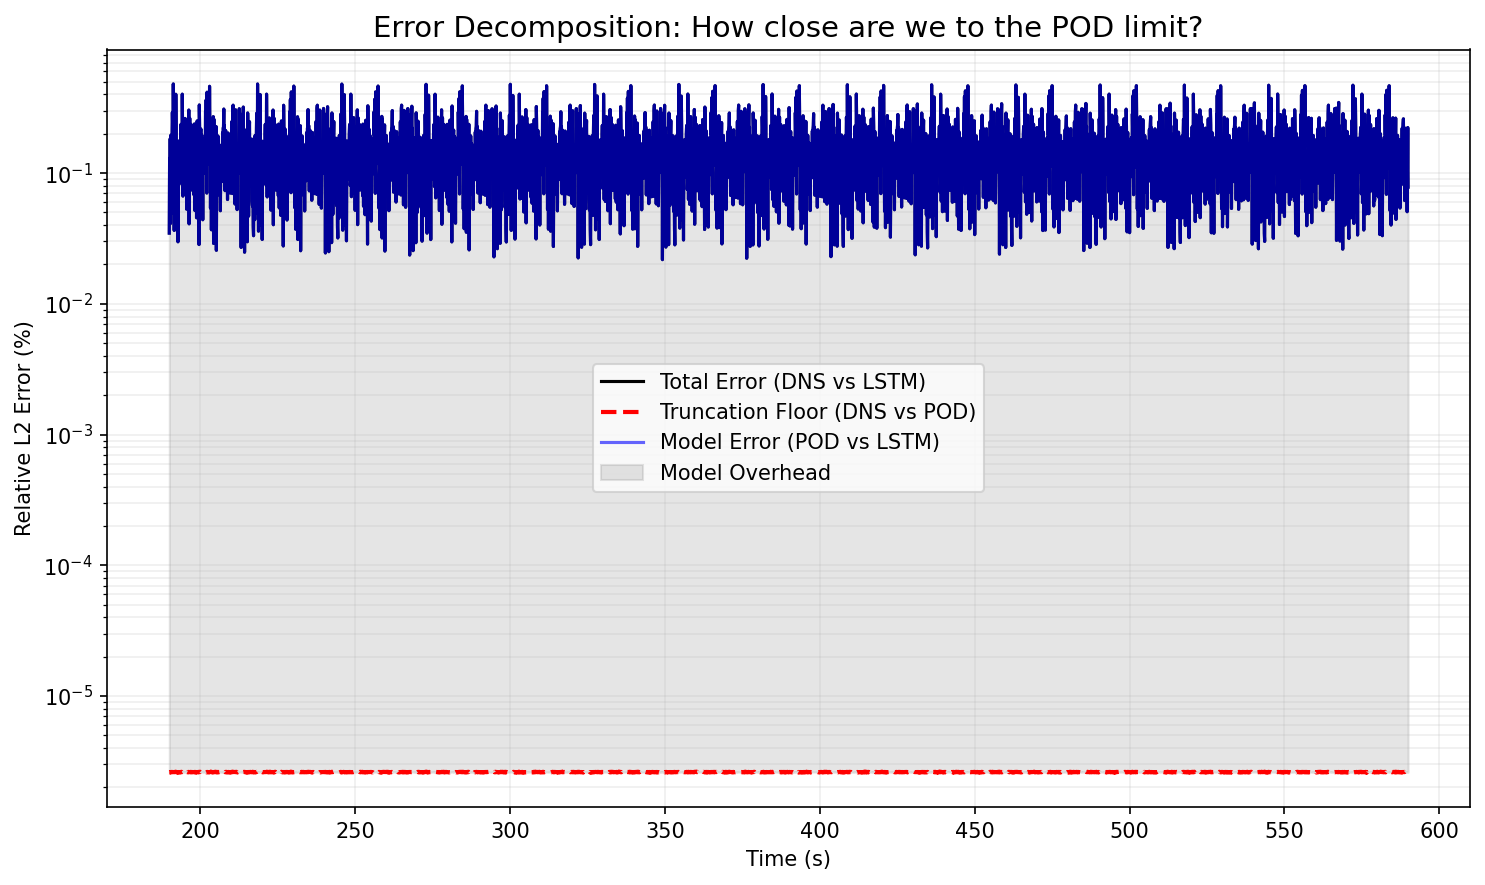

Mean Total Error: 0.1457%
Mean Truncation Floor: 0.0000%
The model is 55645.31x above the truncation limit.


In [4]:
import os
import h5py
import numpy as np
import matplotlib.pyplot as plt

# 1. Config & Paths
output_dir = "/media/chris-remote/Projects/ONeill/estimation/output/DNS_CC_Re150_Mazi"
results_h5 = os.path.join(output_dir, "inference_results.h5")
data_path = os.path.join(output_dir, "lstm_ready_data.h5")

# 2. Load Data
with h5py.File(results_h5, 'r') as f:
    ux_pred = f['ux_pred'][:]
    uy_pred = f['uy_pred'][:]
    ux_true = f['ux_true'][:] # This is the original DNS
    uy_true = f['uy_true'][:]
    time = f['time'][:]

with h5py.File(data_path, 'r') as f_pod:
    phi_ff = f_pod['phi_ff'][:]
    mean_ff = f_pod['mean_ff'][:]
    # We need the ground truth coefficients for the test set
    a_ff_true = f_pod['test/a_ff'][:]

# The test set was 4100, inference was 4000. Align them.
seq_len = 100
a_ff_true_aligned = a_ff_true[seq_len:] 

# 3. Reconstruct the "True POD" (The Truncated Representation)
# This is what a perfect model would achieve.
n_points = mean_ff.shape[0] // 2
ux_pod = mean_ff[:n_points] + a_ff_true_aligned @ phi_ff[:, :n_points]
uy_pod = mean_ff[n_points:] + a_ff_true_aligned @ phi_ff[:, n_points:]

# 4. Calculate Error Components (L2 Relative)
def get_l2(pred, target):
    num = np.sum((pred - target)**2, axis=1)
    den = np.sum(target**2, axis=1)
    return np.sqrt(num / den)

# Total Error: DNS vs LSTM
err_total = (get_l2(ux_pred, ux_true) + get_l2(uy_pred, uy_true)) / 2

# Truncation Error: DNS vs POD (The Theoretical Floor)
err_trunc = (get_l2(ux_pod, ux_true) + get_l2(uy_pod, uy_true)) / 2

# Model Error: POD vs LSTM (The Model's failure to predict coefficients)
err_model = (get_l2(ux_pred, ux_pod) + get_l2(uy_pred, uy_pod)) / 2

# 5. Plotting the Comparison
plt.figure(figsize=(10, 6), dpi=150)
plt.plot(time, err_total * 100, label='Total Error (DNS vs LSTM)', color='black', lw=1.5)
plt.plot(time, err_trunc * 100, label='Truncation Floor (DNS vs POD)', color='red', linestyle='--', lw=2)
plt.plot(time, err_model * 100, label='Model Error (POD vs LSTM)', color='blue', alpha=0.6)

plt.fill_between(time, err_trunc*100, err_total*100, color='gray', alpha=0.2, label='Model Overhead')

plt.yscale('log') # Log scale is often better for seeing how close we get to the floor
plt.title("Error Decomposition: How close are we to the POD limit?", fontsize=14)
plt.xlabel("Time (s)")
plt.ylabel("Relative L2 Error (%)")
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.2)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, "error_decomposition.png"))
plt.show()

print(f"Mean Total Error: {np.mean(err_total)*100:.4f}%")
print(f"Mean Truncation Floor: {np.mean(err_trunc)*100:.4f}%")
print(f"The model is {np.mean(err_total)/np.mean(err_trunc):.2f}x above the truncation limit.")